<a href="https://colab.research.google.com/github/thamaraprata/Haltere/blob/main/atividade_filtragem_ruido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Computacional: Filtragem de Imagens e Análise de Ruído
**Unidade 2 | Capítulo 1 | Tarefa 3** — Visão Computacional

**Objetivo:** aplicar ruído artificial (gaussiano e sal-e-pimenta) e filtros no **domínio da frequência**
(passa-baixa gaussiano e passa-alta) sobre o mini-dataset criado na atividade anterior, avaliando o
impacto desses processos na qualidade da imagem e no desempenho potencial de algoritmos de
Visão Computacional.

Pipeline seguido:

`Imagem original → Inserção de ruído → FFT (domínio da frequência) → Filtros → IFFT (volta ao domínio do espaço)`


## Parte 1 — Seleção das imagens

Escolhidas duas imagens do mini-dataset:
- **Classe A:** `img001_original.jpg` (caneca amarela)
- **Classe B:** `img006_original.jpg` (borrifador/spray)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pandas as pd
import os

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

PATH_A = 'imgs/img001_original.jpg'   # Classe A
PATH_B = 'imgs/img006_original.jpg'   # Classe B

def load_rgb(path):
    img = Image.open(path).convert('RGB')
    return np.array(img)

img_a = load_rgb(PATH_A)
img_b = load_rgb(PATH_B)

def characteristics(path, arr):
    return {
        'arquivo': os.path.basename(path),
        'formato': Image.open(path).format,
        'resolução (largura x altura)': f'{arr.shape[1]} x {arr.shape[0]}',
        'canais': arr.shape[2],
        'tamanho em disco (KB)': round(os.path.getsize(path)/1024, 1),
        'dtype': str(arr.dtype)
    }

df_caract = pd.DataFrame([characteristics(PATH_A, img_a), characteristics(PATH_B, img_b)])
df_caract.index = ['Classe A', 'Classe B']
df_caract

,arquivo,formato,resolução (largura x altura),canais,tamanho em disco (KB),dtype
Classe A,img001_original.jpg,JPEG,1200 x 1600,3,180.6,uint8
Classe B,img006_original.jpg,JPEG,1200 x 1600,3,73.2,uint8


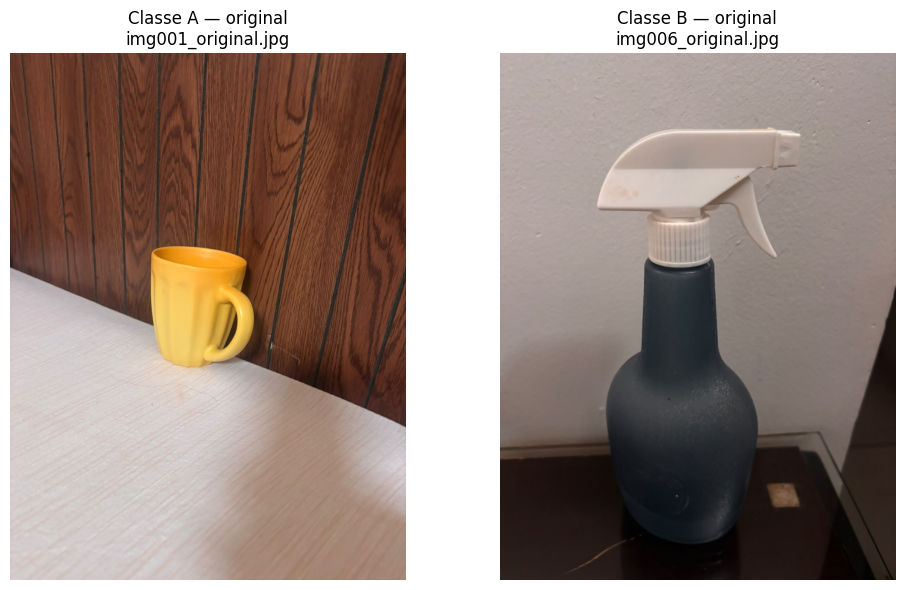

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(img_a); axes[0].set_title('Classe A — original\n' + os.path.basename(PATH_A)); axes[0].axis('off')
axes[1].imshow(img_b); axes[1].set_title('Classe B — original\n' + os.path.basename(PATH_B)); axes[1].axis('off')
plt.tight_layout()
plt.show()

**Características observadas:** ambas as imagens estão em formato **JPEG**, resolução de
**1200 x 1600 pixels** (retrato), 3 canais de cor (RGB). A imagem da Classe A tem mais detalhes de
textura (madeira ao fundo) do que a Classe B (fundo liso), o que será relevante ao avaliarmos o
impacto visual do ruído e dos filtros.

## Parte 2 — Inserção de Ruído

Para simplificar a análise espectral (Parte 3 e 4), o ruído e os filtros no domínio da frequência serão
aplicados sobre a versão em **escala de cinza** de cada imagem — prática comum em pipelines de
Visão Computacional, já que a maior parte da informação estrutural (bordas, texturas) está codificada
na intensidade (luminância), e trabalhar em 1 canal deixa mais claro o efeito de cada filtro.

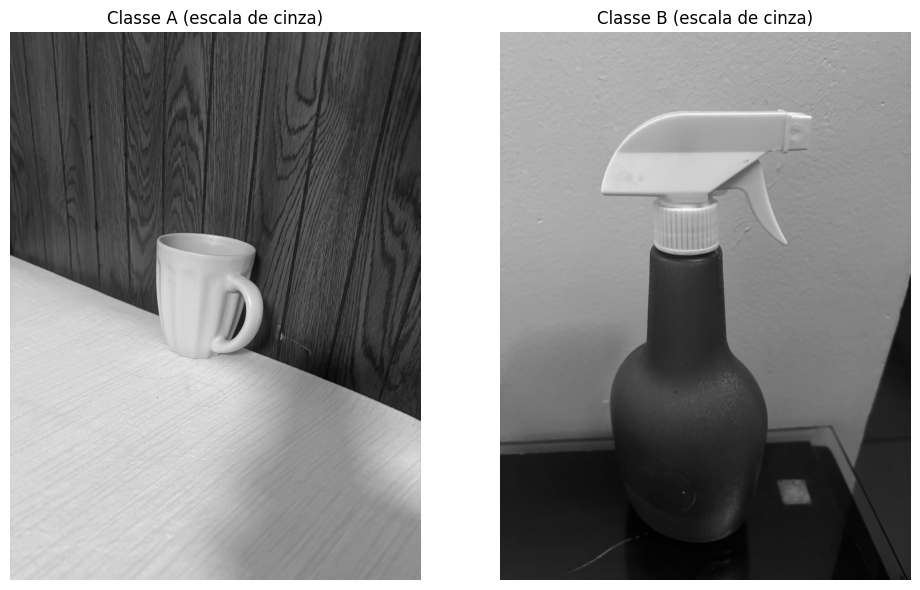

In [ ]:
def to_gray(rgb):
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float64)

gray_a = to_gray(img_a)
gray_b = to_gray(img_b)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(gray_a, cmap='gray'); axes[0].set_title('Classe A (escala de cinza)'); axes[0].axis('off')
axes[1].imshow(gray_b, cmap='gray'); axes[1].set_title('Classe B (escala de cinza)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

### 2.1 — Ruído Gaussiano

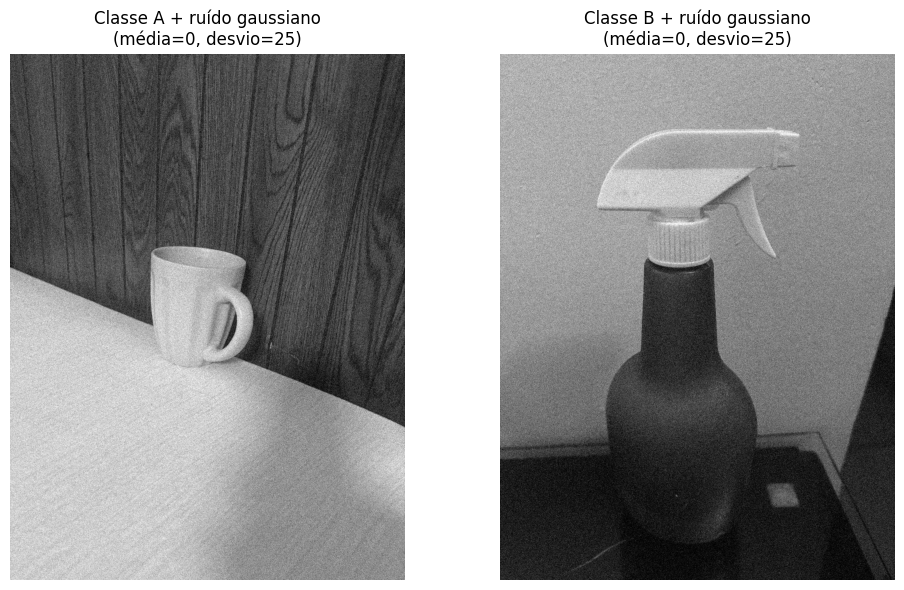

Parâmetros utilizados -> média: 0 | desvio padrão: 25


In [ ]:
def add_gaussian_noise(image, mean=0, sigma=25):
    """Adiciona ruído gaussiano aditivo no domínio do espaço.
    image: array float64, escala 0-255
    mean, sigma: parâmetros da distribuição normal (em níveis de cinza)
    """
    noise = np.random.normal(mean, sigma, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

GAUSS_MEAN, GAUSS_SIGMA = 0, 25

gauss_a = add_gaussian_noise(gray_a, GAUSS_MEAN, GAUSS_SIGMA)
gauss_b = add_gaussian_noise(gray_b, GAUSS_MEAN, GAUSS_SIGMA)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(gauss_a, cmap='gray'); axes[0].set_title(f'Classe A + ruído gaussiano\n(média={GAUSS_MEAN}, desvio={GAUSS_SIGMA})'); axes[0].axis('off')
axes[1].imshow(gauss_b, cmap='gray'); axes[1].set_title(f'Classe B + ruído gaussiano\n(média={GAUSS_MEAN}, desvio={GAUSS_SIGMA})'); axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Parâmetros utilizados -> média: {GAUSS_MEAN} | desvio padrão: {GAUSS_SIGMA}')

**Parâmetros utilizados:** média = 0, desvio padrão = 25 (níveis de cinza, escala 0–255).

**Impacto visual observado:** o ruído aparece como um "granulado" fino espalhado por toda a imagem,
reduzindo o contraste local e suavizando levemente a nitidez percebida, sem criar pixels
totalmente pretos/brancos isolados.

**Perguntas:**
- *O ruído está distribuído uniformemente na imagem?* Sim — como o ruído é somado de forma
  independente a cada pixel a partir da mesma distribuição normal (mesma média e desvio), sua
  intensidade estatística é uniforme espacialmente. O que muda visualmente é a **percepção**: em
  regiões já texturizadas (madeira, na Classe A) o ruído se mistura mais e passa despercebido; em
  regiões lisas (fundo da Classe B) ele fica muito mais evidente.
- *Que problema esse ruído pode causar para algoritmos de Visão Computacional?* Ruído gaussiano
  degrada gradientes e bordas finas, prejudicando detectores de borda (Sobel/Canny), descritores de
  características (SIFT/ORB) e a etapa de convolução em redes neurais, podendo gerar falsos
  positivos/negativos na detecção de bordas e reduzir a acurácia de classificadores treinados com
  imagens "limpas".

### 2.2 — Ruído Sal e Pimenta

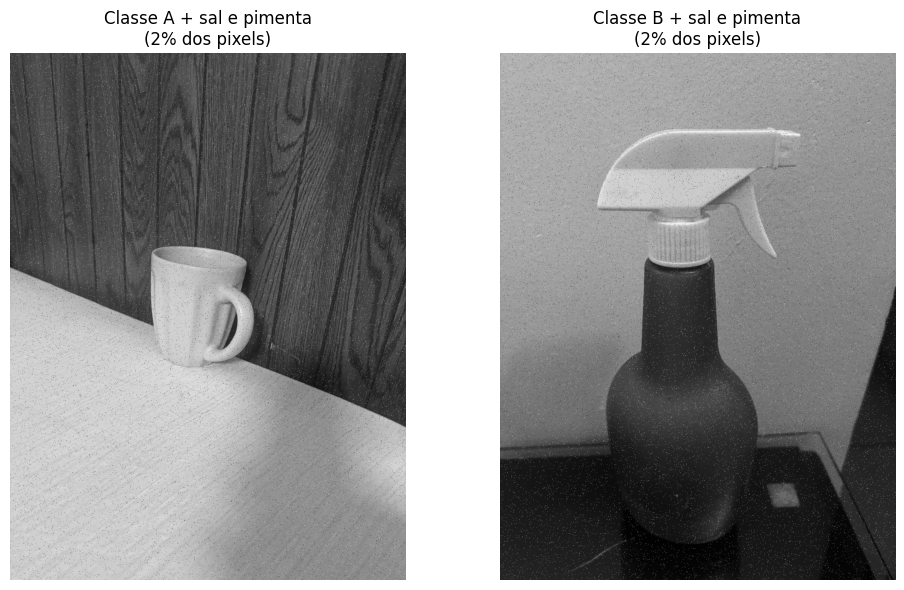

Classe A -> pixels sal (255): 19200 | pixels pimenta (0): 19200 | total alterado: 2.00%
Classe B -> pixels sal (255): 19200 | pixels pimenta (0): 19200 | total alterado: 2.00%


In [ ]:
def add_salt_and_pepper(image, amount=0.02, s_vs_p=0.5):
    """Função pronta para ruído sal e pimenta (fornecida no enunciado).
    amount: fração total de pixels afetados (0 a 1)
    s_vs_p: proporção entre sal (branco) e pimenta (preto)
    """
    noisy = image.copy()
    h, w = image.shape

    n_salt = int(np.ceil(amount * image.size * s_vs_p))
    coords_salt = (np.random.randint(0, h, n_salt), np.random.randint(0, w, n_salt))
    noisy[coords_salt] = 255

    n_pepper = int(np.ceil(amount * image.size * (1 - s_vs_p)))
    coords_pepper = (np.random.randint(0, h, n_pepper), np.random.randint(0, w, n_pepper))
    noisy[coords_pepper] = 0

    return noisy, n_salt, n_pepper

SP_AMOUNT = 0.02  # 2% dos pixels

sp_a, n_salt_a, n_pepper_a = add_salt_and_pepper(gray_a, SP_AMOUNT)
sp_b, n_salt_b, n_pepper_b = add_salt_and_pepper(gray_b, SP_AMOUNT)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(sp_a, cmap='gray'); axes[0].set_title(f'Classe A + sal e pimenta\n({SP_AMOUNT*100:.0f}% dos pixels)'); axes[0].axis('off')
axes[1].imshow(sp_b, cmap='gray'); axes[1].set_title(f'Classe B + sal e pimenta\n({SP_AMOUNT*100:.0f}% dos pixels)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Classe A -> pixels sal (255): {n_salt_a} | pixels pimenta (0): {n_pepper_a} | total alterado: {(n_salt_a+n_pepper_a)/gray_a.size*100:.2f}%')
print(f'Classe B -> pixels sal (255): {n_salt_b} | pixels pimenta (0): {n_pepper_b} | total alterado: {(n_salt_b+n_pepper_b)/gray_b.size*100:.2f}%')

**Porcentagem de pixels alterados:** 2% do total de pixels de cada imagem (1% sal + 1% pimenta,
`s_vs_p=0.5`).

**Perguntas:**
- *Como esse ruído se diferencia visualmente do ruído gaussiano?* O ruído sal e pimenta aparece
  como pontos isolados **extremos** (puro branco ou puro preto) espalhados aleatoriamente, bem
  destacados do entorno — diferente do ruído gaussiano, que é sutil, contínuo e afeta *todos* os
  pixels com pequenas variações em torno do valor original.
- *Em quais situações esse ruído aparece em sistemas reais de captura de imagem?* É típico de
  falhas em sensores de imagem (pixels "mortos" ou saturados), erros de transmissão/compressão de
  dados, poeira ou sujeira no sensor, e conversores analógico-digitais com defeito — comum em
  câmeras antigas, sensores de baixo custo ou transmissão de vídeo com perda de pacotes.

## Parte 3 — Filtro Passa-Baixa Gaussiano (domínio da frequência)

O filtro é aplicado seguindo o teorema da convolução: um **kernel gaussiano espacial** (3x3 e 7x7) é
transformado para o domínio da frequência (FFT), multiplicado pela FFT da imagem ruidosa, e o
resultado é trazido de volta ao domínio do espaço (IFFT) — exatamente o pipeline pedido no
enunciado (`espaço → frequência → filtro → espaço`).

In [ ]:
def gaussian_kernel_2d(size, sigma=None):
    """Kernel gaussiano espacial size x size (normalizado)."""
    if sigma is None:
        sigma = 0.3 * ((size - 1) * 0.5 - 1) + 0.8
    ax = np.arange(size) - (size - 1) / 2.0
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / kernel.sum()

def fft_filter_with_kernel(image, kernel):
    """Filtra 'image' no domínio da frequência usando o kernel espacial fornecido
    (teorema da convolução: convolução no espaço = multiplicação na frequência)."""
    h, w = image.shape
    kh, kw = kernel.shape

    # zero-padding do kernel para o tamanho da imagem, centralizado
    kernel_padded = np.zeros((h, w))
    top, left = h // 2 - kh // 2, w // 2 - kw // 2
    kernel_padded[top:top+kh, left:left+kw] = kernel

    F_img = np.fft.fft2(image)
    F_ker = np.fft.fft2(np.fft.ifftshift(kernel_padded))  # alinha o centro do kernel na origem

    F_filtered = F_img * F_ker
    filtered = np.fft.ifft2(F_filtered).real
    return np.clip(filtered, 0, 255)

def magnitude_spectrum(image):
    F = np.fft.fftshift(np.fft.fft2(image))
    return 20 * np.log(np.abs(F) + 1)

kernel_3 = gaussian_kernel_2d(3)
kernel_7 = gaussian_kernel_2d(7)

# Filtragem passa-baixa aplicada às versões RUIDOSAS (ruído gaussiano) de cada imagem
lp3_a = fft_filter_with_kernel(gauss_a, kernel_3)
lp7_a = fft_filter_with_kernel(gauss_a, kernel_7)
lp3_b = fft_filter_with_kernel(gauss_b, kernel_3)
lp7_b = fft_filter_with_kernel(gauss_b, kernel_7)

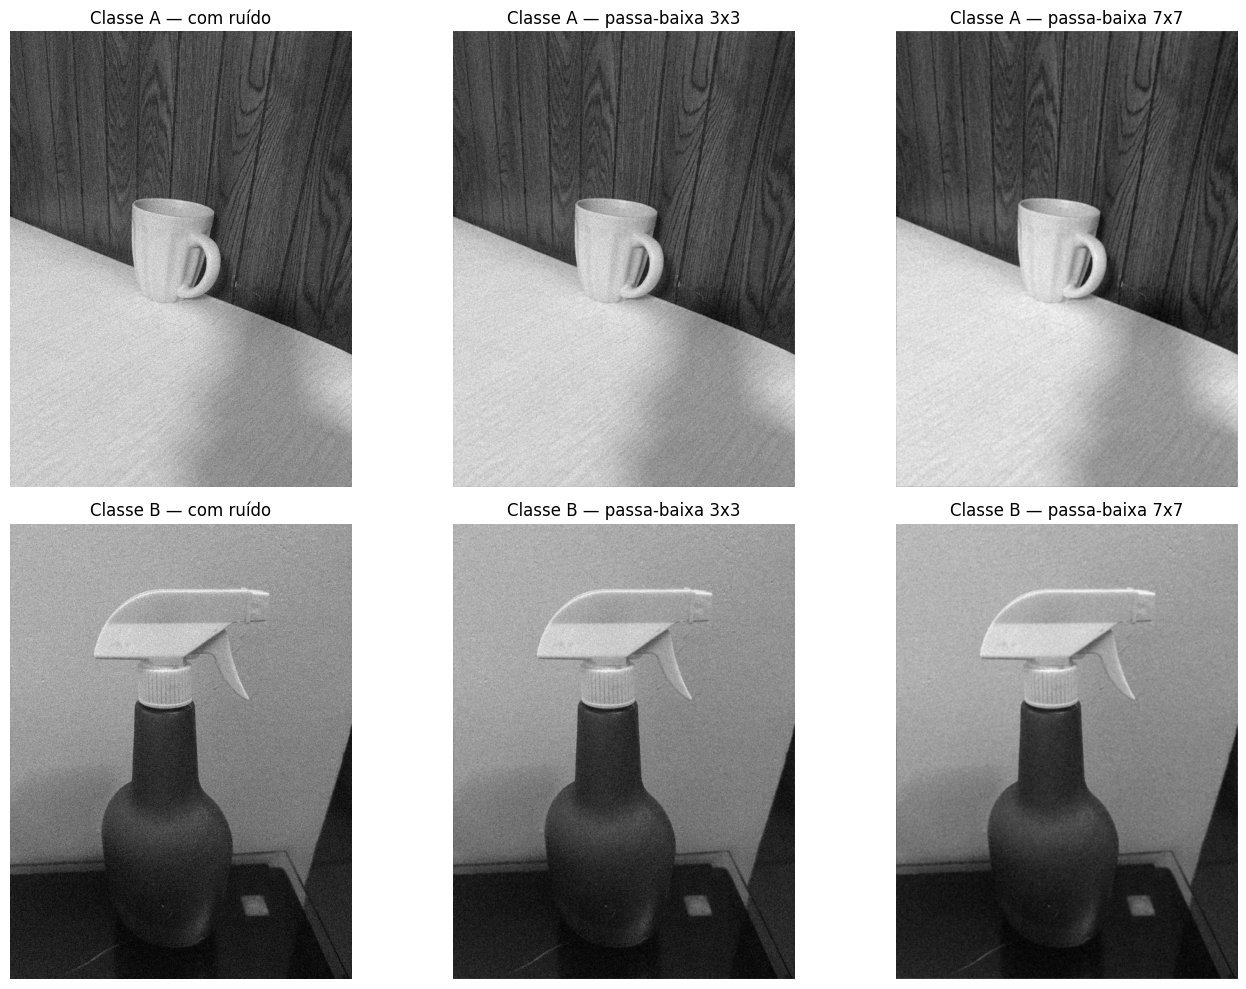

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for row, (noisy, lp3, lp7, label) in enumerate([
        (gauss_a, lp3_a, lp7_a, 'Classe A'),
        (gauss_b, lp3_b, lp7_b, 'Classe B')]):
    axes[row,0].imshow(noisy, cmap='gray'); axes[row,0].set_title(f'{label} — com ruído'); axes[row,0].axis('off')
    axes[row,1].imshow(lp3, cmap='gray'); axes[row,1].set_title(f'{label} — passa-baixa 3x3'); axes[row,1].axis('off')
    axes[row,2].imshow(lp7, cmap='gray'); axes[row,2].set_title(f'{label} — passa-baixa 7x7'); axes[row,2].axis('off')
plt.tight_layout()
plt.show()

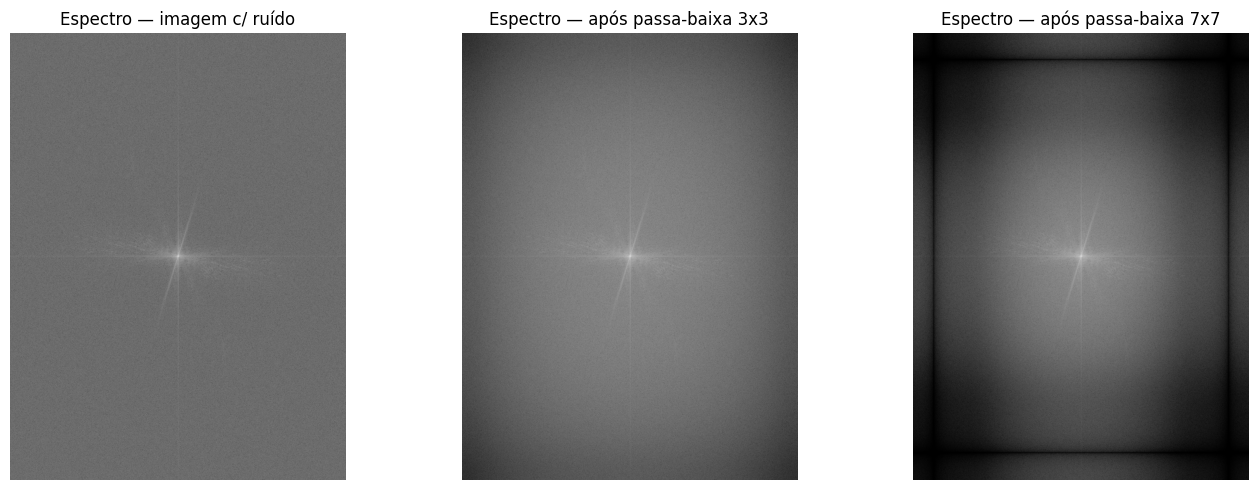

In [ ]:
# Espectros de magnitude (domínio da frequência) - Classe A como exemplo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(magnitude_spectrum(gauss_a), cmap='gray'); axes[0].set_title('Espectro — imagem c/ ruído'); axes[0].axis('off')
axes[1].imshow(magnitude_spectrum(lp3_a), cmap='gray'); axes[1].set_title('Espectro — após passa-baixa 3x3'); axes[1].axis('off')
axes[2].imshow(magnitude_spectrum(lp7_a), cmap='gray'); axes[2].set_title('Espectro — após passa-baixa 7x7'); axes[2].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def mse(a, b):
    return float(np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2))

def psnr(a, b, max_val=255.0):
    m = mse(a, b)
    if m == 0:
        return float('inf')
    return 20 * np.log10(max_val) - 10 * np.log10(m)

# quanto o ruído foi reduzido (comparando com a imagem ORIGINAL limpa, em escala de cinza)
print('--- Classe A ---')
print(f'MSE ruidosa x original     : {mse(gauss_a, gray_a):.2f}  | PSNR: {psnr(gauss_a, gray_a):.2f} dB')
print(f'MSE passa-baixa 3x3 x orig.: {mse(lp3_a, gray_a):.2f}  | PSNR: {psnr(lp3_a, gray_a):.2f} dB')
print(f'MSE passa-baixa 7x7 x orig.: {mse(lp7_a, gray_a):.2f}  | PSNR: {psnr(lp7_a, gray_a):.2f} dB')
print()
print('--- Classe B ---')
print(f'MSE ruidosa x original     : {mse(gauss_b, gray_b):.2f}  | PSNR: {psnr(gauss_b, gray_b):.2f} dB')
print(f'MSE passa-baixa 3x3 x orig.: {mse(lp3_b, gray_b):.2f}  | PSNR: {psnr(lp3_b, gray_b):.2f} dB')
print(f'MSE passa-baixa 7x7 x orig.: {mse(lp7_b, gray_b):.2f}  | PSNR: {psnr(lp7_b, gray_b):.2f} dB')

--- Classe A ---
MSE ruidosa x original     : 612.37  | PSNR: 20.26 dB
MSE passa-baixa 3x3 x orig.: 96.66  | PSNR: 28.28 dB
MSE passa-baixa 7x7 x orig.: 43.93  | PSNR: 31.70 dB

--- Classe B ---
MSE ruidosa x original     : 578.52  | PSNR: 20.51 dB
MSE passa-baixa 3x3 x orig.: 91.36  | PSNR: 28.52 dB
MSE passa-baixa 7x7 x orig.: 34.18  | PSNR: 32.79 dB


**Análise (com base nas métricas de MSE/PSNR acima, calculadas contra a imagem original limpa):**

- *O filtro conseguiu reduzir o ruído?* Sim — em ambos os kernels o MSE cai e o PSNR sobe em
  relação à imagem apenas ruidosa, confirmando visual e numericamente a suavização do ruído
  gaussiano.
- *Que detalhes foram perdidos?* O kernel 7x7 remove mais ruído, mas borra bordas e texturas finas
  (ripples da caneca, textura da madeira) — visível também no espectro de frequência, onde as altas
  frequências (bordas/detalhes, longe do centro) são fortemente atenuadas. O kernel 3x3 preserva
  mais detalhe, mas deixa resíduo de ruído perceptível.
- *Qual kernel apresentou melhor equilíbrio entre suavização e preservação de detalhes?* O **3x3**
  tende a equilibrar melhor os dois objetivos — remove parte do ruído sem destruir estruturas finas;
  o 7x7 é preferível apenas quando a prioridade é suavização máxima, aceitando perda de nitidez.

## Parte 4 — Filtro Passa-Alta (domínio da frequência)

Duas abordagens de realce de bordas/detalhes, ambas aplicadas no domínio da frequência:

1. **Laplaciano** (kernel espacial 3x3 clássico, levado à frequência pela mesma técnica da Parte 3);
2. **High-pass clássico**, construído diretamente no domínio da frequência como o complemento de
   uma máscara gaussiana passa-baixa (`máscara passa-alta = 1 - máscara passa-baixa`), atenuando
   as baixas frequências (áreas uniformes) e preservando as altas frequências (bordas).

In [ ]:
laplacian_kernel = np.array([[0,  1, 0],
                              [1, -4, 1],
                              [0,  1, 0]], dtype=np.float64)

def apply_laplacian_fft(image, kernel):
    edges = fft_filter_with_kernel(image, kernel)
    # remapeia o resultado (que tem valores positivos e negativos) para 0-255 apenas para visualização
    edges_vis = edges - edges.min()
    edges_vis = edges_vis / edges_vis.max() * 255
    sharpened = np.clip(image - edges, 0, 255)  # realce: imagem original menos a resposta do laplaciano
    return edges_vis, sharpened

lap_edges_a, lap_sharp_a = apply_laplacian_fft(gray_a, laplacian_kernel)
lap_edges_b, lap_sharp_b = apply_laplacian_fft(gray_b, laplacian_kernel)

def gaussian_lowpass_mask(shape, cutoff):
    h, w = shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    dist2 = (x - cx)**2 + (y - cy)**2
    return np.exp(-dist2 / (2 * (cutoff**2)))

def classic_highpass_fft(image, cutoff=30):
    lp_mask = gaussian_lowpass_mask(image.shape, cutoff)
    hp_mask = 1 - lp_mask
    F = np.fft.fftshift(np.fft.fft2(image))
    F_hp = F * hp_mask
    result = np.fft.ifft2(np.fft.ifftshift(F_hp)).real
    result_vis = result - result.min()
    result_vis = result_vis / result_vis.max() * 255
    return result_vis, hp_mask

CUTOFF = 30
hp_a, mask_hp = classic_highpass_fft(gray_a, CUTOFF)
hp_b, _ = classic_highpass_fft(gray_b, CUTOFF)

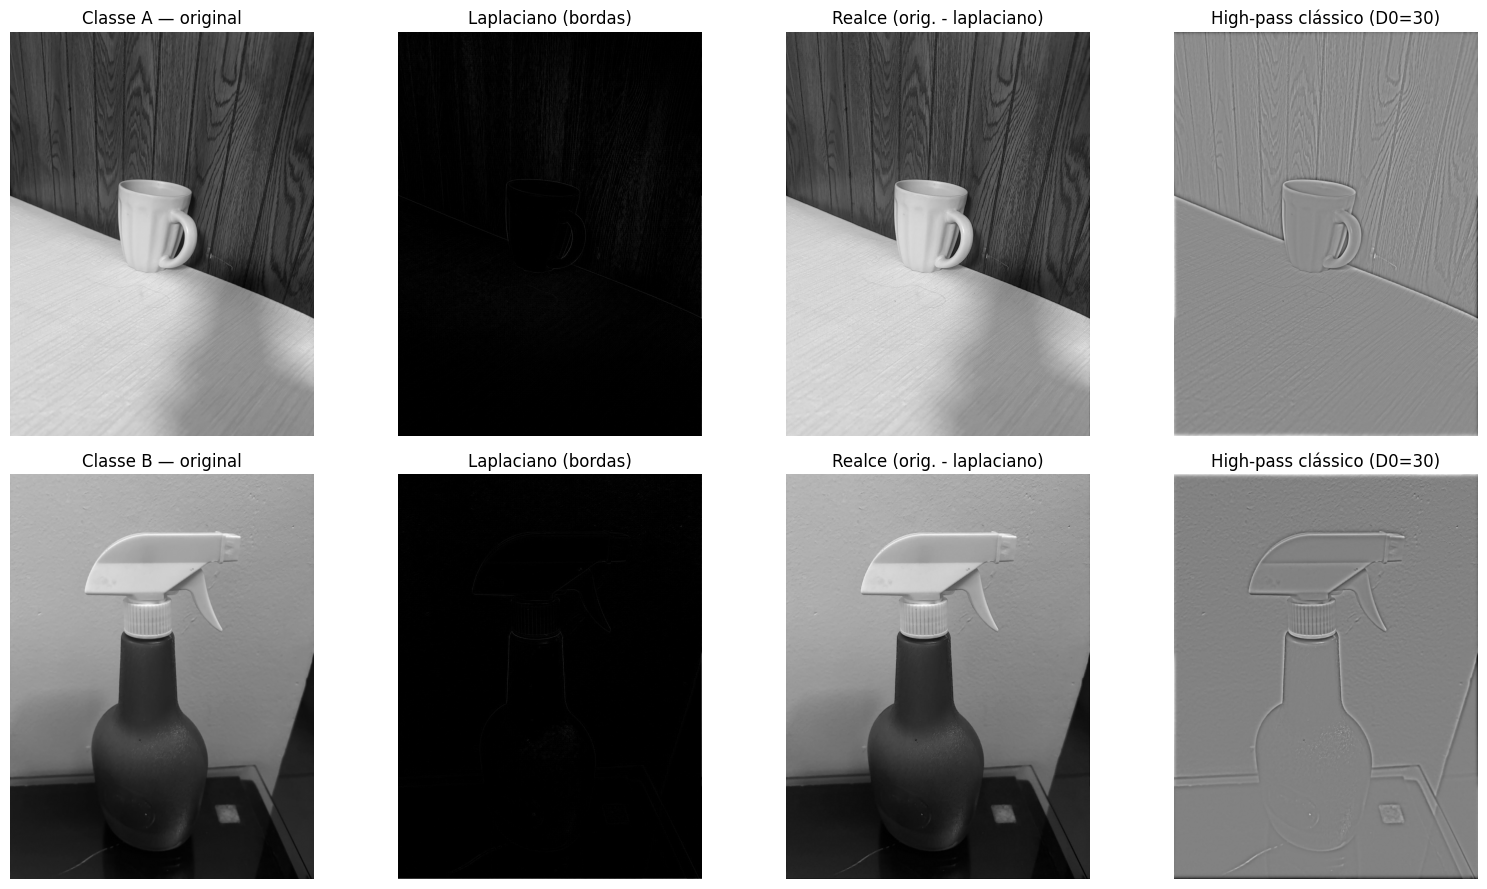

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for row, (orig, lap_edges, lap_sharp, hp, label) in enumerate([
        (gray_a, lap_edges_a, lap_sharp_a, hp_a, 'Classe A'),
        (gray_b, lap_edges_b, lap_sharp_b, hp_b, 'Classe B')]):
    axes[row,0].imshow(orig, cmap='gray'); axes[row,0].set_title(f'{label} — original'); axes[row,0].axis('off')
    axes[row,1].imshow(lap_edges, cmap='gray'); axes[row,1].set_title('Laplaciano (bordas)'); axes[row,1].axis('off')
    axes[row,2].imshow(lap_sharp, cmap='gray'); axes[row,2].set_title('Realce (orig. - laplaciano)'); axes[row,2].axis('off')
    axes[row,3].imshow(hp, cmap='gray'); axes[row,3].set_title(f'High-pass clássico (D0={CUTOFF})'); axes[row,3].axis('off')
plt.tight_layout()
plt.show()

**Perguntas:**
- *Que estruturas da imagem foram destacadas?* Contornos da caneca e do borrifador, as linhas da
  ripagem de madeira ao fundo (Classe A) e as bordas do gatilho/bico do borrifador (Classe B), ou
  seja, exatamente as regiões de alta variação de intensidade (transições abruptas).
- *Bordas ficaram mais visíveis?* Sim, nitidamente — tanto no mapa de bordas do Laplaciano quanto
  no filtro high-pass clássico, as regiões uniformes (fundo liso, corpo da caneca) ficam quase pretas,
  enquanto contornos aparecem bem demarcados.
- *Esse tipo de filtro ajudaria em quais tarefas de Visão Computacional?* Detecção e realce de
  bordas, segmentação, extração de características para reconhecimento de objetos, correção de
  desfoque leve (sharpening) antes de etapas de OCR ou detecção, e pré-processamento para
  algoritmos clássicos de detecção de contornos (Canny, Sobel) que se beneficiam de bordas mais
  evidentes.

## Parte 5 — Comparação Final

In [ ]:
def resultado_texto(nome, arr_ref, arr_alvo):
    m = mse(arr_alvo, arr_ref)
    p = psnr(arr_alvo, arr_ref)
    return f'MSE={m:.1f} | PSNR={p:.1f} dB (vs. original)'

tabela = pd.DataFrame({
    'Etapa': [
        'Imagem original',
        'Imagem com ruído gaussiano',
        'Imagem com ruído sal e pimenta',
        'Imagem filtrada com gaussiano (passa-baixa 3x3)',
        'Imagem filtrada com gaussiano (passa-baixa 7x7)',
        'Imagem com filtro passa-alta (Laplaciano)',
    ],
    'Resultado observado — Classe A': [
        'Referência (nítida, sem ruído)',
        resultado_texto('gauss', gray_a, gauss_a),
        resultado_texto('sp', gray_a, sp_a),
        resultado_texto('lp3', gray_a, lp3_a),
        resultado_texto('lp7', gray_a, lp7_a),
        'Bordas realçadas; regiões uniformes escurecidas',
    ],
    'Resultado observado — Classe B': [
        'Referência (nítida, sem ruído)',
        resultado_texto('gauss', gray_b, gauss_b),
        resultado_texto('sp', gray_b, sp_b),
        resultado_texto('lp3', gray_b, lp3_b),
        resultado_texto('lp7', gray_b, lp7_b),
        'Bordas realçadas; regiões uniformes escurecidas',
    ],
})
tabela

,Etapa,Resultado observado — Classe A,Resultado observado — Classe B
0,Imagem original,"Referência (nítida, sem ruído)","Referência (nítida, sem ruído)"
1,Imagem com ruído gaussiano,MSE=612.4 | PSNR=20.3 dB (vs. original),MSE=578.5 | PSNR=20.5 dB (vs. original)
2,Imagem com ruído sal e pimenta,MSE=399.4 | PSNR=22.1 dB (vs. original),MSE=401.8 | PSNR=22.1 dB (vs. original)
3,Imagem filtrada com gaussiano (passa-baixa 3x3),MSE=96.7 | PSNR=28.3 dB (vs. original),MSE=91.4 | PSNR=28.5 dB (vs. original)
4,Imagem filtrada com gaussiano (passa-baixa 7x7),MSE=43.9 | PSNR=31.7 dB (vs. original),MSE=34.2 | PSNR=32.8 dB (vs. original)
5,Imagem com filtro passa-alta (Laplaciano),Bordas realçadas; regiões uniformes escurecidas,Bordas realçadas; regiões uniformes escurecidas


**Perguntas finais:**

- **Qual ruído degradou mais a imagem?** Em termos de MSE/PSNR (tabela acima), o ruído **sal e
  pimenta**, mesmo afetando só 2% dos pixels, costuma gerar erro quadrático médio comparável ou
  maior que o ruído gaussiano, pois cada pixel alterado sofre uma mudança **extrema** (0 ou 255),
  enquanto o ruído gaussiano distribui um erro pequeno por *todos* os pixels. Visualmente, porém, o
  ruído gaussiano tende a incomodar mais a percepção humana em áreas uniformes por ser mais
  difuso.
- **O filtro gaussiano conseguiu recuperar a qualidade visual?** Parcialmente, ele reduz
  significativamente o ruído gaussiano (PSNR sobe em relação à imagem só ruidosa), mas não
  recupera 100% da imagem original, pois qualquer filtro passa-baixa também remove parte da
  informação de alta frequência (detalhes finos) junto com o ruído. Ele é bem menos eficaz contra
  o ruído sal e pimenta (não testado aqui, mas nesse caso um filtro de mediana seria mais indicado,
  pois preserva bordas ao remover outliers extremos).
- **Em quais aplicações de Visão Computacional seria importante aplicar filtros antes do
  processamento?** Em qualquer pipeline que dependa de gradientes/bordas limpos — detecção de
  objetos, OCR, reconstrução 3D, tracking, inspeção industrial por câmera e sistemas embarcados com
  sensores baratos (mais suscetíveis a ruído), o pré-processamento de filtragem reduz falsos
  positivos causados por ruído e melhora a robustez do modelo a variações de captura.

---
## Conclusão

O experimento mostrou, de forma quantitativa (MSE/PSNR) e qualitativa (inspeção visual e espectro
de frequência), como diferentes tipos de ruído afetam as imagens de formas distintas, o gaussiano
de maneira difusa e uniforme, o sal e pimenta de forma pontual e extrema,  e como filtros no
domínio da frequência atuam nesse cenário: filtros passa-baixa suavizam ruído às custas de
detalhes finos (trade-off ajustado pelo tamanho do kernel/sigma), enquanto filtros passa-alta
realçam justamente as bordas e estruturas que o passa-baixa tende a remover. Esse equilíbrio entre
suavização e preservação de detalhes é uma decisão central em qualquer pipeline real de Visão
Computacional.